In [21]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv('loan_data.csv')

# Shape of dataset
df.shape

# Column names
df.columns

# Data types
df.dtypes

# First 5 rows
df.head()

# Last 5 rows
df.tail()


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y
613,LP002990,Female,No,0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,N


In [22]:
# Check missing values
df.isnull().sum()


,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [23]:
# Categorical columns - fill with mode
cat_cols = ['Gender','Married','Dependents','Self_Employed','Credit_History','Loan_Amount_Term']
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Numerical columns - fill with median
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)


/tmp/ipython-input-2929614143.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipython-input-2929614143.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

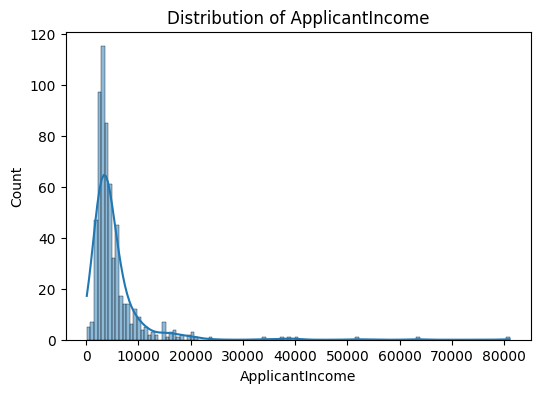

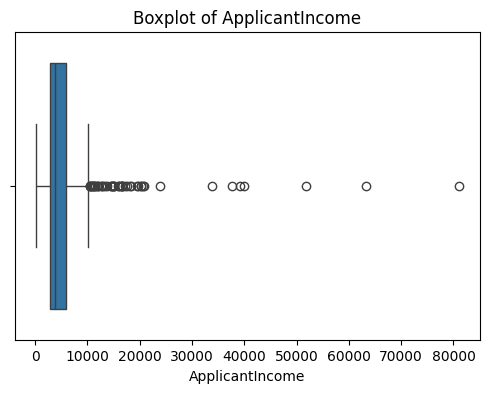

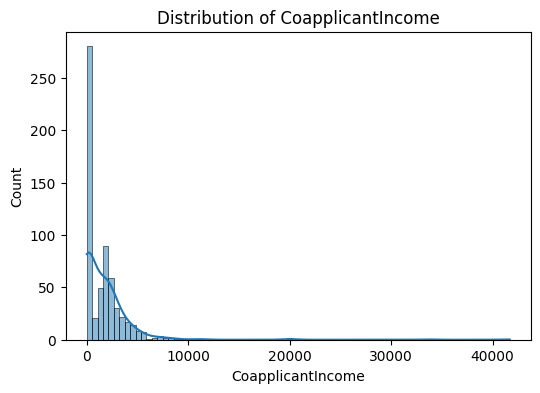

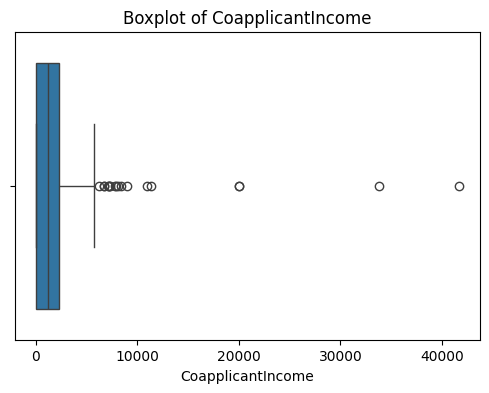

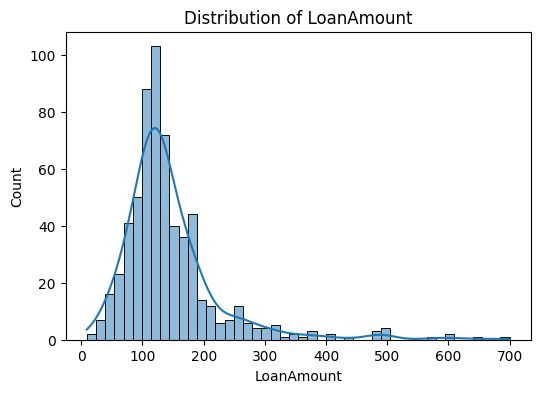

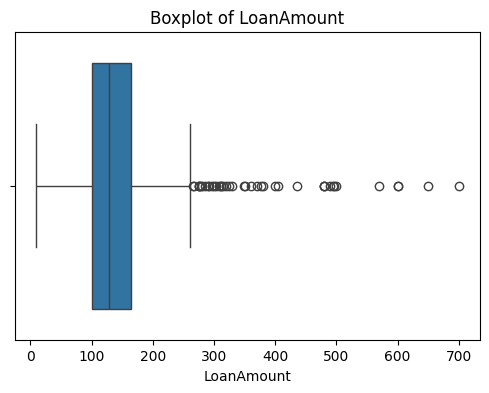

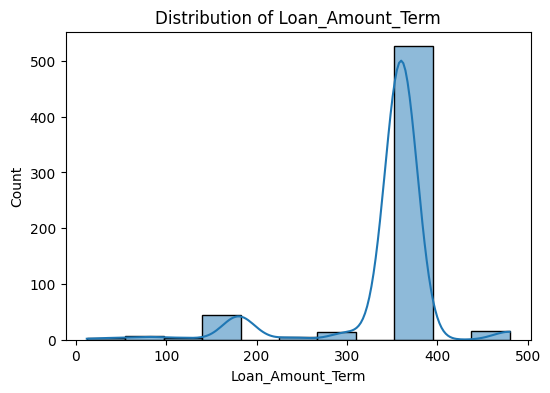

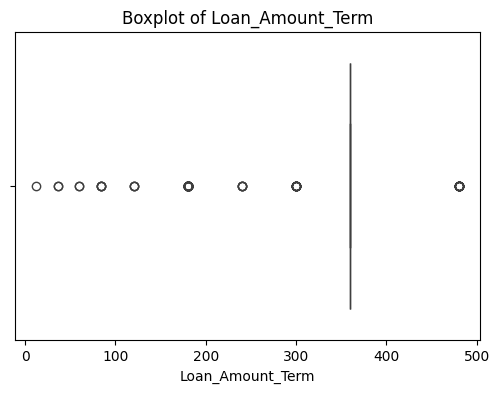

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term']

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()


Gender
Male      502
Female    112
Name: count, dtype: int64


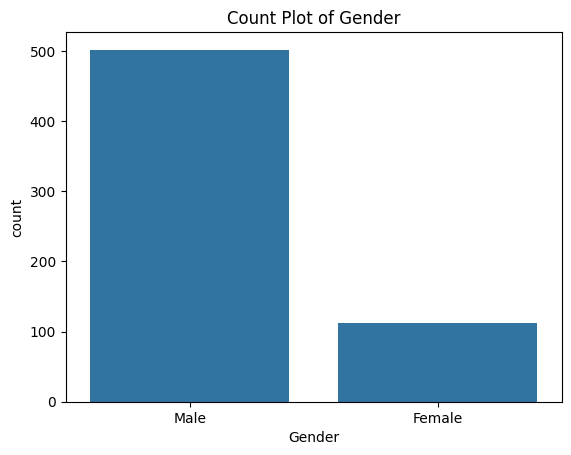

Married
Yes    401
No     213
Name: count, dtype: int64


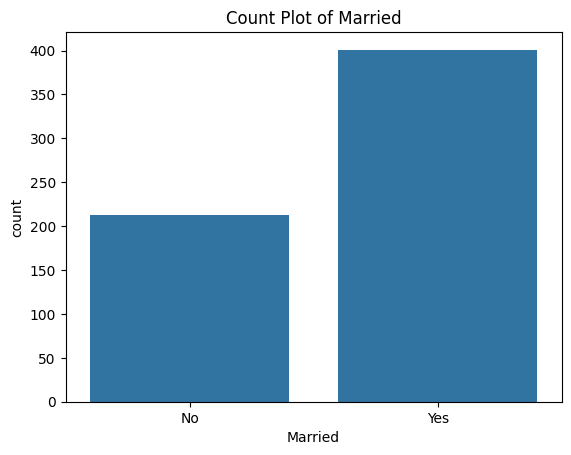

Education
Graduate        480
Not Graduate    134
Name: count, dtype: int64


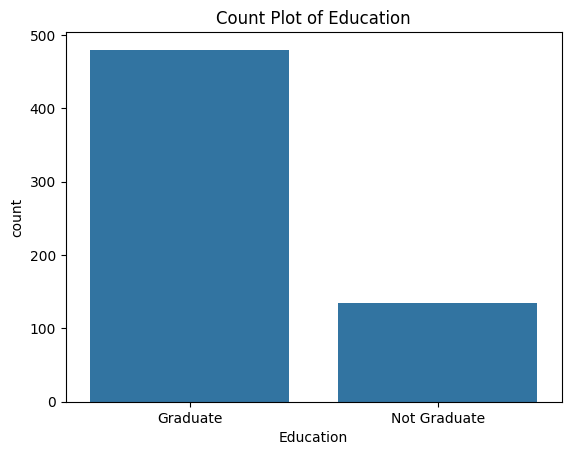

Self_Employed
No     532
Yes     82
Name: count, dtype: int64


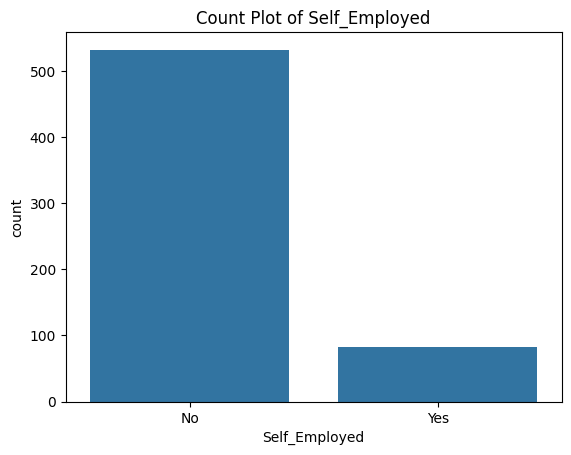

Property_Area
Semiurban    233
Urban        202
Rural        179
Name: count, dtype: int64


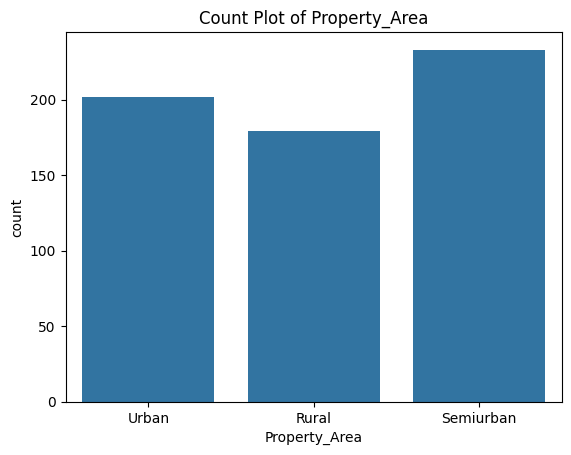

Loan_Status
Y    422
N    192
Name: count, dtype: int64


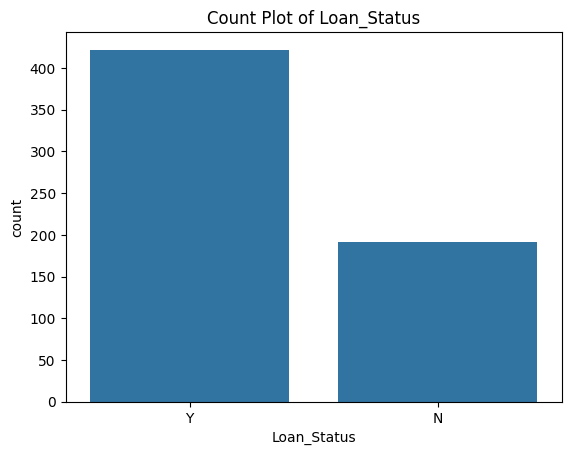

In [25]:
cat_cols = ['Gender','Married','Education','Self_Employed','Property_Area','Loan_Status']

for col in cat_cols:
    print(df[col].value_counts())
    sns.countplot(x=col, data=df)
    plt.title(f'Count Plot of {col}')
    plt.show()


In [26]:
pd.crosstab(df['Education'], df['Loan_Status'], normalize='index')


Loan_Status,N,Y
Education,,
Graduate,0.291667,0.708333
Not Graduate,0.388060,0.611940


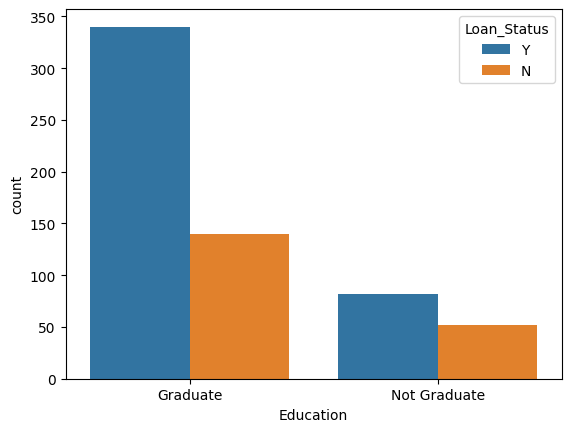

In [27]:
sns.countplot(x='Education', hue='Loan_Status', data=df)
plt.show()


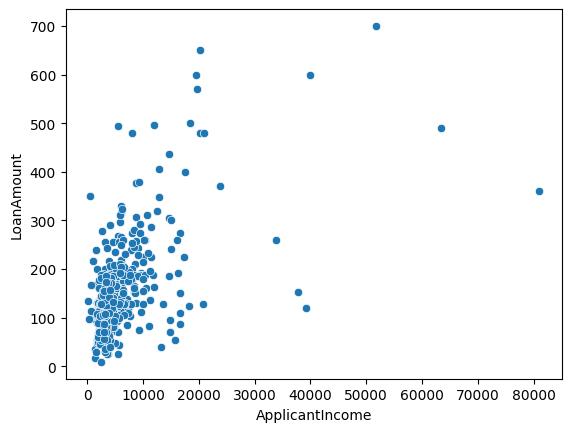

,ApplicantIncome,LoanAmount
ApplicantIncome,1.000000,0.565181
LoanAmount,0.565181,1.000000


In [28]:
sns.scatterplot(x='ApplicantIncome', y='LoanAmount', data=df)
plt.show()

df[['ApplicantIncome','LoanAmount']].corr()


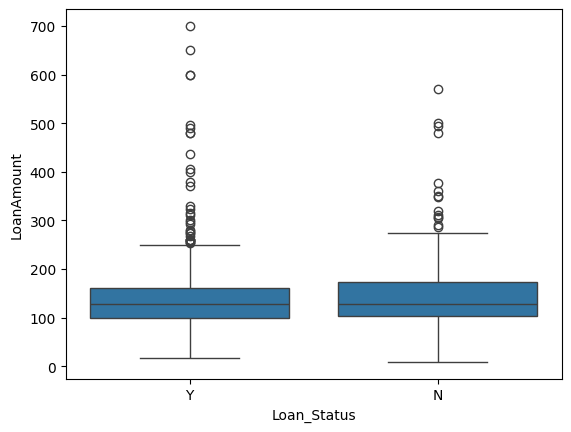

In [29]:
sns.boxplot(x='Loan_Status', y='LoanAmount', data=df)
plt.show()


In [30]:
df.groupby('Loan_Status')['ApplicantIncome'].mean()
df.groupby('Property_Area')['Loan_Status'].value_counts(normalize=True)


Property_Area  Loan_Status
Rural          Y              0.614525
               N              0.385475
Semiurban      Y              0.768240
               N              0.231760
Urban          Y              0.658416
               N              0.341584
Name: proportion, dtype: float64